In [3]:
# updated version
import pandas as pd
import numpy as np
import os

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
path = "."

files = [f for f in os.listdir(path) if f.endswith('.csv')]

df_list = []
for file in files:
    full_path = os.path.join(path, file)
    data = pd.read_csv(full_path, low_memory=False)
    df_list.append(data)
print(files)

['test.csv', 'train.csv']


In [6]:
if len(df_list) == 0:
    print("No CSV files found!")
else:
    df = pd.concat(df_list, ignore_index=True)
    print("Dataset Shape:", df.shape)

Dataset Shape: (185559, 42)


In [7]:
import os
print(os.getcwd())
print(os.listdir())

c:\Users\kalug\Downloads\IDS_kafka
['.git', 'docker-compose.yml', 'gitattributes (1)', 'Isolation_forest.ipynb', 'Kmeans+xgboost.ipynb', 'lof.ipynb', 'PCA (Principal Component Analysis) + XGBoost.ipynb', 'Random Forest + XGBoost.ipynb', 'README.md', 'test.csv', 'train.csv', 'venv']


In [8]:
import os
import pandas as pd

path = "."

files = [f for f in os.listdir(path) if f.endswith('.csv')]
print("Files found:", files)

df_list = []

for file in files:
    full_path = os.path.join(path, file)
    data = pd.read_csv(full_path, low_memory=False)
    df_list.append(data)

if len(df_list) == 0:
    print("No CSV files found!")
else:
    df = pd.concat(df_list, ignore_index=True)
    print("Dataset Shape:", df.shape)

Files found: ['test.csv', 'train.csv']
Dataset Shape: (185559, 42)


In [9]:
print(df.columns)

Index(['duration', 'protocol_type', 'service', 'flag', 'src_bytes',
       'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot',
       'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell',
       'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
       'num_access_files', 'num_outbound_cmds', 'is_host_login',
       'is_guest_login', 'count', 'srv_count', 'serror_rate',
       'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
       'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
       'dst_host_srv_count', 'dst_host_same_srv_rate',
       'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
       'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
       'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
       'dst_host_srv_rerror_rate', 'class'],
      dtype='str')


In [10]:
df['class'] = df['class'].apply(lambda x: 0 if x == 'normal' else 1)

In [11]:
df = df.select_dtypes(include=['number'])

df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

print("After cleaning:", df.shape)

After cleaning: (185559, 39)


In [12]:
df.rename(columns={'class': 'Label'}, inplace=True)
X = df.drop('Label', axis=1)
y = df['Label']

In [13]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.01)
X = selector.fit_transform(X)

In [14]:
import pandas as pd

X_df = pd.DataFrame(X)

corr_matrix = X_df.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]

X_df.drop(columns=to_drop, inplace=True)

X = X_df.values

print("Remaining features:", X.shape)

Remaining features: (185559, 23)


In [15]:
print(df['Label'].value_counts())
print(df['Label'].unique())

Label
1    92904
0    92655
Name: count, dtype: int64
[1 0]


In [16]:
from sklearn.utils import resample

df_normal = df[df['Label'] == 0]
df_attack = df[df['Label'] == 1]

# ✅ Fix: balance using minimum class size
n_samples = min(len(df_normal), len(df_attack))

df_normal_down = resample(
    df_normal,
    replace=False,
    n_samples=n_samples,
    random_state=42
)

df_attack_down = resample(
    df_attack,
    replace=False,
    n_samples=n_samples,
    random_state=42
)

# Combine + shuffle
df_balanced = pd.concat([df_normal_down, df_attack_down]).sample(frac=1)

# Update X and y
X = df_balanced.drop('Label', axis=1)
y = df_balanced['Label']

print("Balanced:\n", y.value_counts())

Balanced:
 Label
0    92655
1    92655
Name: count, dtype: int64


In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [20]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [21]:
y_pred = model.predict(X_test)

In [22]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.995763855161621
Precision: 0.9960069069717246
Recall: 0.9955234345504558
F1 Score: 0.995765112076174


Accuracy: 0.9959581806423798
Precision: 0.9963675792897805
Recall: 0.9955040355343697
F1 Score: 0.9959356202243538


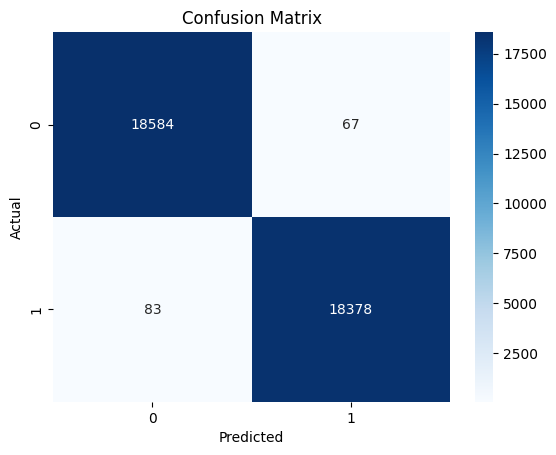

In [23]:
#IMPORTS
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from xgboost import XGBClassifier

#LOAD DATA

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

df = pd.concat([train, test], ignore_index=True)


#LABEL PROCESSING
# Convert label
df['class'] = df['class'].apply(lambda x: 0 if x == 'normal' else 1)
df.rename(columns={'class': 'Label'}, inplace=True)


#KEEP ONLY NUMERIC
df = df.select_dtypes(include=[np.number])

df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)


#SPLIT X and y
X = df.drop('Label', axis=1)
y = df['Label']

#TRAIN TEST SPLIT (VERY IMPORTANT)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#SCALING
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

y_train = y_train.values
y_test = y_test.values


#TRAIN ONLY ON NORMAL DATA
X_train_if = X_train[y_train == 0]


iso = IsolationForest(
    contamination=0.1,
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

iso.fit(X_train_if)

#GENERATE ANOMALY SCORES
train_scores = iso.decision_function(X_train)
test_scores = iso.decision_function(X_test)

train_scores = train_scores.reshape(-1, 1)
test_scores = test_scores.reshape(-1, 1)


X_train_hybrid = np.hstack((X_train, train_scores))
X_test_hybrid = np.hstack((X_test, test_scores))

model = XGBClassifier(
    n_estimators=400,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train_hybrid, y_train)

y_pred = model.predict(X_test_hybrid)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
